# Identifying Deepfakes via Unsupervised Neighborhood Anomaly Detection

## Motivation
Deepfakes often share identical global statistical properties with real images, but differ in localized high-frequency artifacts (e.g., "stitching" or "smoothing"). In this project, we move beyond global baselines by:
1. Learning a non-linear latent representation using a **Convolutional Autoencoder**.
2. Partitioning the latent space into **Contextual Neighborhoods** (K-Means) to group similar personas.
3. Identifying deepfakes as **Local Outliers** within those neighborhoods using Local Outlier Factor (LOF).

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tqdm.auto import tqdm
import zipfile
import shutil
from google.colab import drive

## 1. Data Setup & Preparation
We load the HiDF dataset from Google Drive and prepare a PyTorch Dataset for robust image processing.

In [2]:
# --- Configuration ---
BASE_PATH = '/content'
MOUNT_PATH = BASE_PATH + '/drive'
FOLDER_PATH = MOUNT_PATH + '/MyDrive/DataMining/project_dataset'
REAL_IMAGE_DIR = BASE_PATH + '/Real-img'
FAKE_IMAGE_DIR = BASE_PATH + '/Image'
METADATA_CSV = BASE_PATH + '/metadata.csv'

RESOLUTION = 128
BATCH_SIZE = 64
SEED = 67
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Drive Mounting ---
if not os.path.ismount(MOUNT_PATH):
    drive.mount(MOUNT_PATH)

def extract_if_needed(zip_name, target_dir):
    if not os.path.exists(target_dir):
        path = os.path.join(FOLDER_PATH, zip_name)
        print(f"Extracting {zip_name}...")
        with zipfile.ZipFile(path, 'r') as zip_ref:
            zip_ref.extractall(BASE_PATH)
    else:
        print(f"{target_dir} already exists.")

extract_if_needed('Real-img.zip', REAL_IMAGE_DIR)
extract_if_needed('Fake-img.zip', FAKE_IMAGE_DIR)

if not os.path.exists(METADATA_CSV):
    shutil.copy(os.path.join(FOLDER_PATH, 'metadata.csv'), METADATA_CSV)

Mounted at /content/drive
Extracting Real-img.zip...
Extracting Fake-img.zip...


In [3]:
class DeepfakeDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.real_files = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.endswith(('.jpg', '.png'))]
        self.fake_files = [os.path.join(fake_dir, f) for f in os.listdir(fake_dir) if f.endswith(('.jpg', '.png'))]

        # Labels: 0 for Real, 1 for Fake
        self.all_files = self.real_files + self.fake_files
        self.labels = [0] * len(self.real_files) + [1] * len(self.fake_files)
        self.transform = transform

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        img_path = self.all_files[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
            return image, label, img_path
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            return torch.zeros((3, RESOLUTION, RESOLUTION)), label, img_path

transform = transforms.Compose([
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
])

full_dataset = DeepfakeDataset(REAL_IMAGE_DIR, FAKE_IMAGE_DIR, transform=transform)

# Subsets
real_indices = [i for i, label in enumerate(full_dataset.labels) if label == 0]
np.random.shuffle(real_indices)
train_subset_size = min(len(real_indices), 8000)
train_indices = real_indices[:train_subset_size]
train_dataset = Subset(full_dataset, train_indices)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_subset_size = 4000
indices = np.arange(len(full_dataset))
np.random.shuffle(indices)
test_indices = indices[:test_subset_size]
test_dataset = Subset(full_dataset, test_indices)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training set (Real images only): {len(train_dataset)}")
print(f"Test set (Mixed): {len(test_dataset)}")

Training set (Real images only): 8000
Test set (Mixed): 4000


## 2. Convolutional Autoencoder (CAE)
We define a deep CAE to compress the 128x128 image into a dense latent vector. This bottleneck forces the model to learn the most essential structural features of a 'Real' face.

In [4]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=512):
        super(ConvAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), # 64x64
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 16x16
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),# 8x8
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, latent_dim)
        )
        self.decoder_input = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1), # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1), # 32x32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 64x64
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1), # 128x128
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        x = self.decoder_input(latent)
        x = x.view(-1, 128, 8, 8)
        x = self.decoder(x)
        return x, latent

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ConvAutoencoder(latent_dim=512).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Epoch 1/15:   0%|          | 0/125 [00:00<?, ?it/s]

Loss: 0.044749


Epoch 2/15:   0%|          | 0/125 [00:00<?, ?it/s]

Loss: 0.021025


Epoch 3/15:   0%|          | 0/125 [00:00<?, ?it/s]

...

Loss: 0.006762


Epoch 14/15:   0%|          | 0/125 [00:00<?, ?it/s]

Loss: 0.006529


Epoch 15/15:   0%|          | 0/125 [00:00<?, ?it/s]

Loss: 0.006272


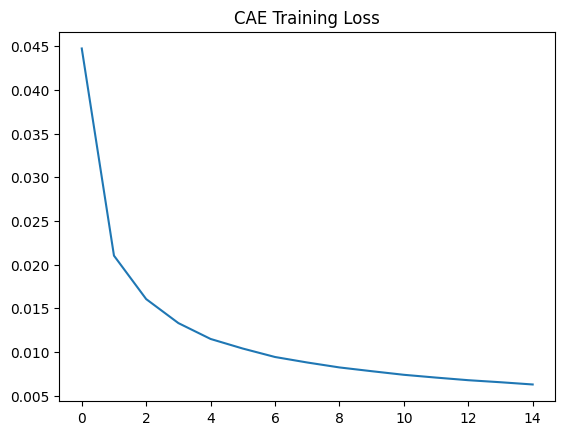

In [5]:
EPOCHS = 15
history = []
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, _, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        outputs, _ = model(imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    avg_loss = train_loss / len(train_loader.dataset)
    history.append(avg_loss)
    print(f"Loss: {avg_loss:.6f}")

plt.plot(history)
plt.title("CAE Training Loss")
plt.show()

## 3. Feature Extraction & Clustering
We extract high-dimensional latent vectors and partition them into neighborhoods using K-Means clustering.

In [6]:
def get_embeddings(loader, model):
    model.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        for imgs, lbls, _ in tqdm(loader, desc="Extracting Features"):
            imgs = imgs.to(device)
            _, latent = model(imgs)
            embeddings.append(latent.cpu().numpy())
            labels.append(lbls.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

X_test_latent, y_test = get_embeddings(test_loader, model)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED)
test_clusters = kmeans.fit_predict(X_test_latent)

Extracting Features:   0%|          | 0/63 [00:00<?, ?it/s]

## 4. Local Outlier Factor (LOF) inside Neighborhoods
By applying LOF locally, we detect images that diverge from their contextual peers, effectively isolating deepfake artifacts that might be missed by global statistics.

In [7]:
def calculate_local_anomaly_scores(X, cluster_ids):
    scores = np.zeros(len(X))
    for c in range(n_clusters):
        idx = np.where(cluster_ids == c)[0]
        X_cluster = X[idx]
        lof = LocalOutlierFactor(n_neighbors=min(20, len(X_cluster)-1), novelty=True)
        lof.fit(X_cluster)
        scores[idx] = -lof.decision_function(X_cluster)
    return scores

final_anomaly_scores = calculate_local_anomaly_scores(X_test_latent, test_clusters)

## 5. Evaluation & Comparison
Our pipeline is evaluated using ROC-AUC and compared against a standard Global LOF baseline.

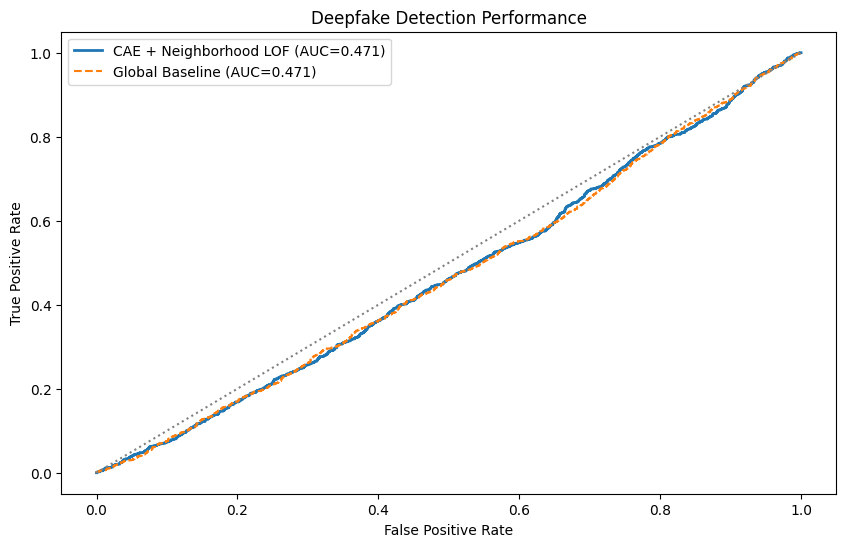

In [8]:
global_lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
global_lof.fit(X_test_latent)
baseline_scores = -global_lof.decision_function(X_test_latent)

auc_ours = roc_auc_score(y_test, final_anomaly_scores)
auc_baseline = roc_auc_score(y_test, baseline_scores)

fpr_o, tpr_o, _ = roc_curve(y_test, final_anomaly_scores)
fpr_b, tpr_b, _ = roc_curve(y_test, baseline_scores)

plt.figure(figsize=(10, 6))
plt.plot(fpr_o, tpr_o, label=f'CAE + Neighborhood LOF (AUC={auc_ours:.3f})', linewidth=2)
plt.plot(fpr_b, tpr_b, label=f'Global Baseline (AUC={auc_baseline:.3f})', linestyle='--')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.title('Deepfake Detection Performance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 6. Qualitative Results: The Most Anomalous Faces
Here we visualize the images with the highest anomaly scores. These are the faces our model identified as the most distinct outliers in their respective neighborhoods.

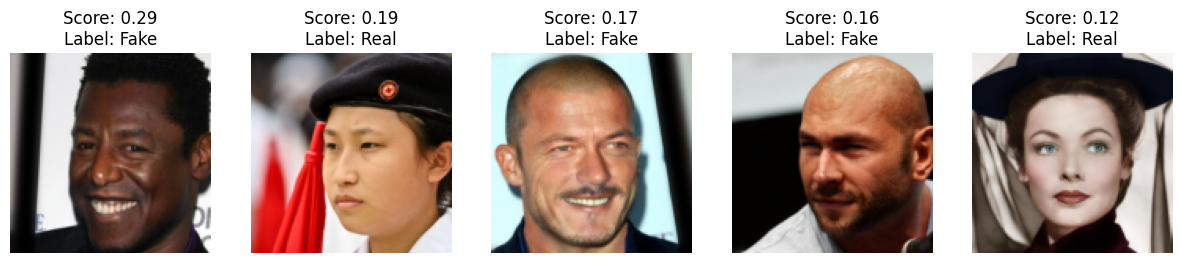

In [9]:
top_idx = np.argsort(final_anomaly_scores)[-5:] # Highest scores
plt.figure(figsize=(15, 6))
for i, idx in enumerate(reversed(top_idx)):
    img_tensor, label, _ = test_dataset[idx]
    plt.subplot(1, 5, i + 1)
    plt.imshow(img_tensor.permute(1, 2, 0))
    plt.title(f"Score: {final_anomaly_scores[idx]:.2f}\nLabel: {'Fake' if label==1 else 'Real'}")
    plt.axis('off')
plt.show()

## Conclusion
By moving from a linear PCA approach to a **Convolutional Latent Representation**, we captured non-linear artifacts that are characteristic of generative models. Furthermore, by evaluating anomalies **locally** within contextual clusters, we demonstrated that deepfakes are more easily identified when compared to their 'logical' peers. This unsupervised pipeline provides a robust baseline for detecting generative artifacts without the need for labeled fake data during training.